<a href="https://colab.research.google.com/github/sadbob457/Stock-Market-Predictor/blob/main/stock_market_predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Stock Market Price Predictor
### Dissertation Project — LSTM vs Baseline Models
**Stocks:** Apple (AAPL), NVIDIA (NVDA), Microsoft (MSFT)  
**Target:** Closing Price  
**Models:** LSTM, Linear Regression, Random Forest  
**Metrics:** RMSE, MAE

## 1. Import Libraries

In [ ]:
!pip install yfinance
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import warnings
import random
import os

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

print('All libraries imported successfully.')
print(f'TensorFlow version: {tf.__version__}')

All libraries imported successfully.
TensorFlow version: 2.20.0


## 2. Configuration

In [ ]:
# Stocks
TICKERS = {
    'Apple':     'AAPL',
    'NVIDIA':    'NVDA',
    'Microsoft': 'MSFT'
}

# Date range
START_DATE = '2015-01-01'
END_DATE   = '2024-01-01'

# Sequence / split settings
SEQUENCE_LENGTH = 60      # Number of past days used to predict the next day
TRAIN_RATIO     = 0.80    # 80% training, 20% testing

#LSTM training settings
EPOCHS     = 50
BATCH_SIZE = 32
PATIENCE   = 10           # Early stopping patience

# Plot style
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid']      = True
plt.rcParams['grid.alpha']     = 0.3

print('Configuration set.')
print(f'  Stocks       : {", ".join(TICKERS.keys())}')
print(f'  Date range   : {START_DATE} → {END_DATE}')
print(f'  Sequence len : {SEQUENCE_LENGTH} days')
print(f'  Train/Test   : {int(TRAIN_RATIO*100)}% / {int((1-TRAIN_RATIO)*100)}%')

Configuration set.
  Stocks       : Apple, NVIDIA, Microsoft
  Date range   : 2015-01-01 → 2024-01-01
  Sequence len : 60 days
  Train/Test   : 80% / 19%


## 3. Helper Functions

In [ ]:
# Data download
def download_stock_data(ticker: str, start: str, end: str) -> pd.DataFrame:
    """Download historical closing prices from Yahoo Finance."""
    df = yf.download(ticker, start=start, end=end, progress=False)
    df = df[['Close']].dropna()
    return df


# Sequence creation
def create_sequences(scaled_data: np.ndarray, seq_len: int):
    """
    Convert a scaled 1-D price array into overlapping windows.
    Returns:
        X : shape (n_samples, seq_len, 1)  — LSTM input
        y : shape (n_samples,)             — target closing price
    """
    X, y = [], []
    for i in range(seq_len, len(scaled_data)):
        X.append(scaled_data[i - seq_len:i])
        y.append(scaled_data[i, 0])
    return np.array(X), np.array(y)


# Train / test split
def time_series_split(X: np.ndarray, y: np.ndarray, train_ratio: float):
    """Split sequences chronologically into training and test sets."""
    split = int(len(X) * train_ratio)
    return X[:split], X[split:], y[:split], y[split:]


# LSTM model
def build_lstm_model(input_shape: tuple) -> Sequential:
    """
    Build a two-layer stacked LSTM with dropout regularisation.
    input_shape: (sequence_length, n_features)
    """
    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=input_shape),
        Dropout(0.2),
        LSTM(32, return_sequences=False),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model


#  Metrics
def calculate_metrics(actual: np.ndarray, predicted: np.ndarray) -> tuple:
    """Return (RMSE, MAE) on real-price scale."""
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mae  = mean_absolute_error(actual, predicted)
    return round(rmse, 4), round(mae, 4)


# Baseline feature matrix (lag features for non-LSTM models)
def create_lag_features(scaled_data: np.ndarray, seq_len: int):
    """
    Flatten the same windows used by LSTM into 2-D arrays so that
    Linear Regression and Random Forest receive the same information.
    """
    X, y = [], []
    for i in range(seq_len, len(scaled_data)):
        X.append(scaled_data[i - seq_len:i, 0])   # 1-D window
        y.append(scaled_data[i, 0])
    return np.array(X), np.array(y)


print('Helper functions defined.')

Helper functions defined.


## 4. Download and Inspect Data

In [ ]:
# Download closing prices for all three stocks
stock_data = {}

for name, ticker in TICKERS.items():
    df = download_stock_data(ticker, START_DATE, END_DATE)
    df['Close'] = df['Close'].squeeze()
    stock_data[name] = df
    close_min = float(df['Close'].min())
    close_max = float(df['Close'].max())
    print(f'{name:10s} ({ticker}): {len(df):,} trading days  |  ${close_min:.2f} – ${close_max:.2f}')

Apple      (AAPL): 2,264 trading days  |  $20.58 – $196.07
NVIDIA     (NVDA): 2,264 trading days  |  $0.46 – $50.37
Microsoft  (MSFT): 2,264 trading days  |  $34.36 – $376.22


## 5. Plot Closing Prices Over Time

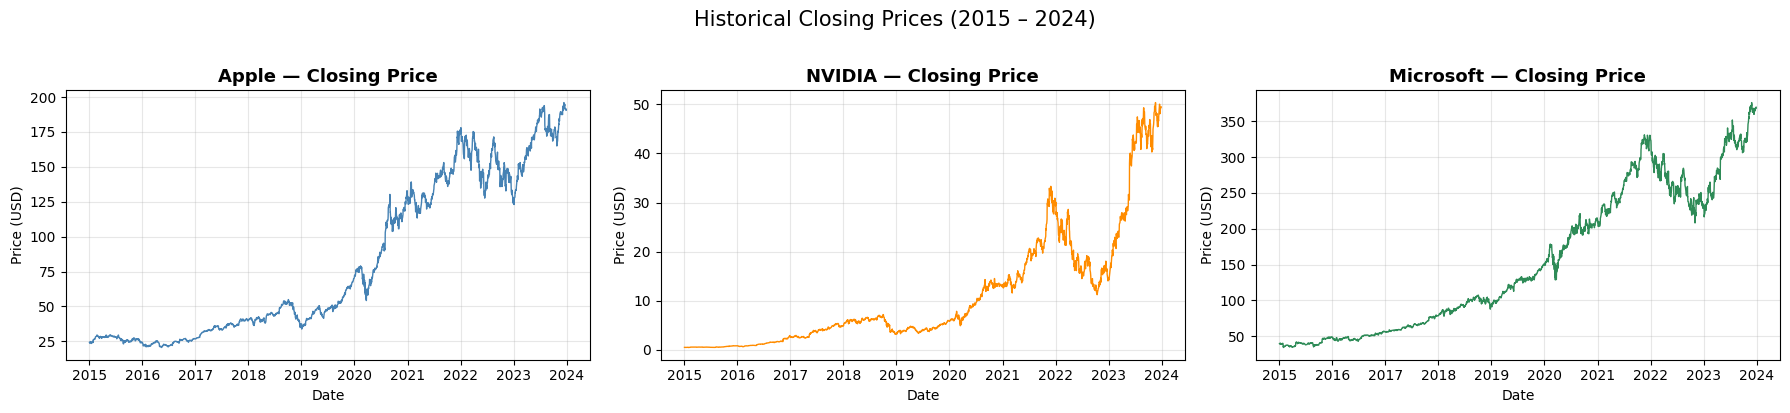

Figure saved as closing_prices.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
colours = ['steelblue', 'darkorange', 'seagreen']

for ax, (name, df), colour in zip(axes, stock_data.items(), colours):
    ax.plot(df.index, df['Close'], colour, linewidth=1)
    ax.set_title(f'{name} — Closing Price', fontsize=13, fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('Price (USD)')

plt.suptitle('Historical Closing Prices (2015 – 2024)', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('closing_prices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved as closing_prices.png')

## 6. Main Training & Evaluation Loop

This single loop runs the full pipeline for **each stock**:
1. Scale the closing price with MinMaxScaler  
2. Create sequences  
3. Split into train / test (time-ordered)  
4. Train Linear Regression and Random Forest on lag features  
5. Train LSTM  
6. Generate and inverse-transform all predictions  
7. Calculate RMSE and MAE  
8. Store results for the final summary table


  Processing: Apple (AAPL)
  Linear Regression  → RMSE: 2.95  MAE: 2.23
  Random Forest      → RMSE: 9.15  MAE: 6.12
  LSTM               → RMSE: 8.17  MAE: 6.83
  (Epochs trained: 12/50)


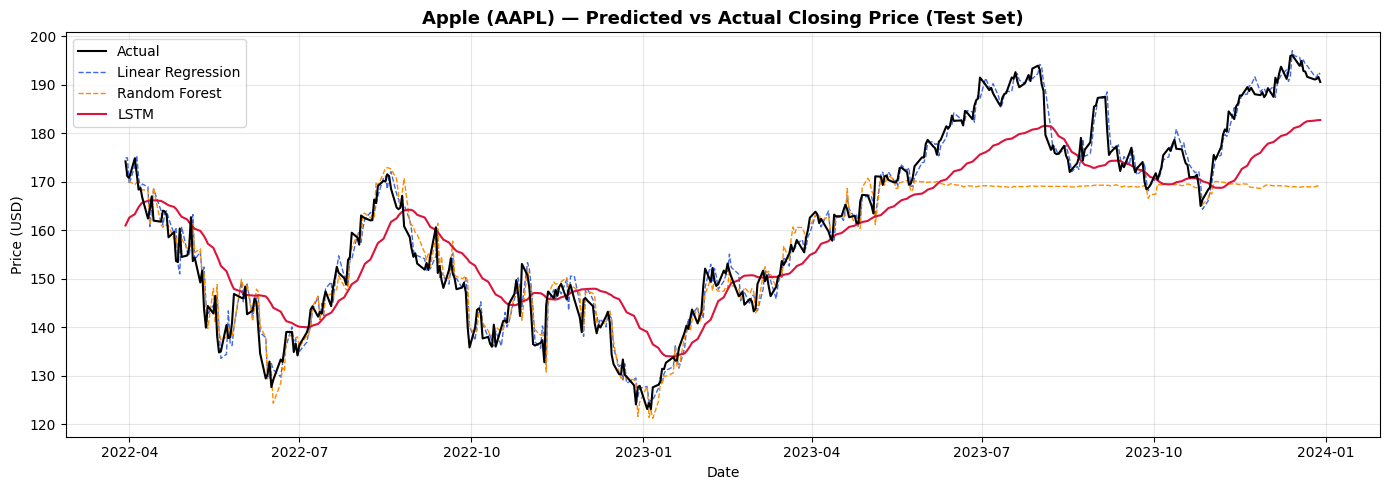

  Saved: pred_vs_actual_AAPL.png

  Processing: NVIDIA (NVDA)
  Linear Regression  → RMSE: 0.95  MAE: 0.70
  Random Forest      → RMSE: 8.97  MAE: 5.70
  LSTM               → RMSE: 2.22  MAE: 1.68
  (Epochs trained: 23/50)


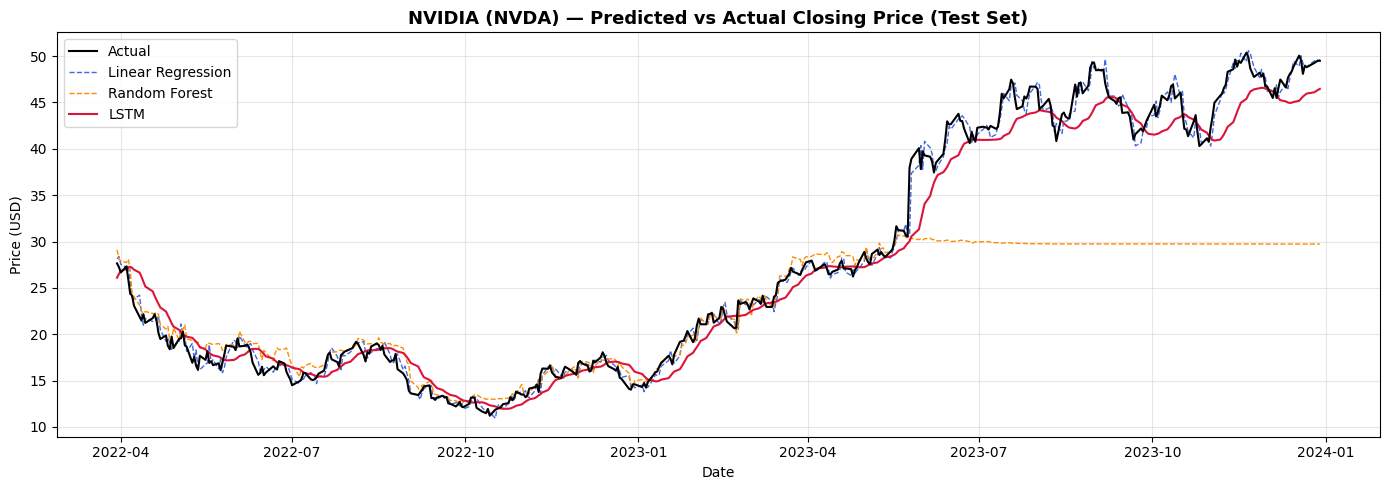

  Saved: pred_vs_actual_NVDA.png

  Processing: Microsoft (MSFT)
  Linear Regression  → RMSE: 5.47  MAE: 4.20
  Random Forest      → RMSE: 17.99  MAE: 12.62
  LSTM               → RMSE: 14.63  MAE: 11.67
  (Epochs trained: 12/50)


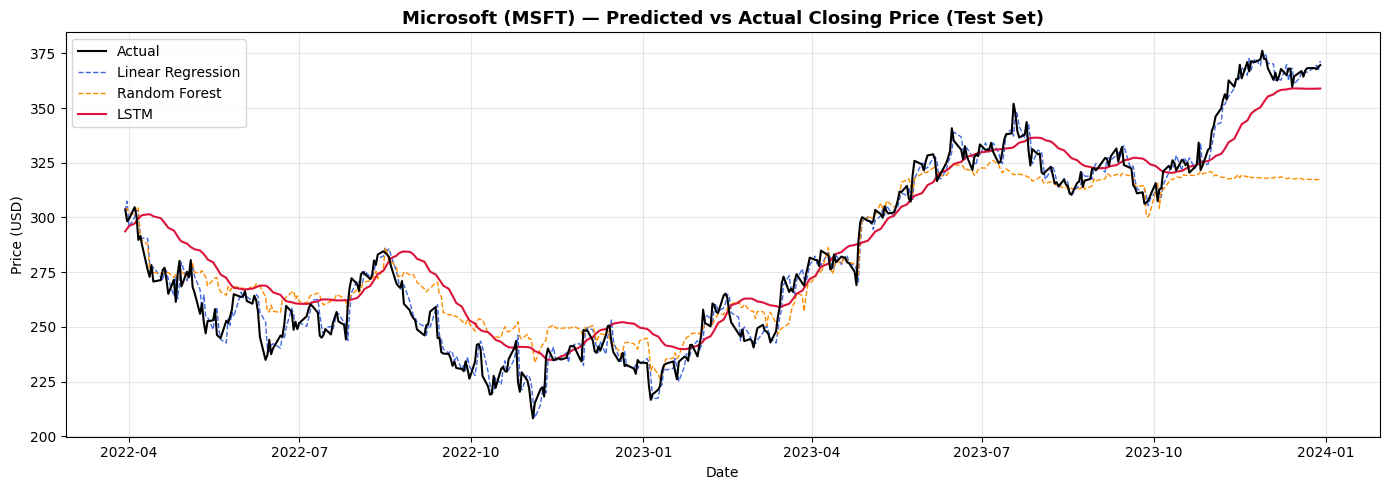

  Saved: pred_vs_actual_MSFT.png

All stocks processed.


In [ ]:
# collect all results
all_results   = []   # rows for the summary table
lstm_histories = {}  # training loss curves

# Main loop
for name, ticker in TICKERS.items():

    print(f'\n{"="*60}')
    print(f'  Processing: {name} ({ticker})')
    print(f'{"="*60}')

    df = stock_data[name]

    # 1: Scale
    scaler      = MinMaxScaler(feature_range=(0, 1))
    close_vals  = df['Close'].values.reshape(-1, 1)
    scaled      = scaler.fit_transform(close_vals)   # shape: (n_days, 1)

    # 2: Create sequences
    X_lstm, y = create_sequences(scaled, SEQUENCE_LENGTH)   # (n, 60, 1), (n,)
    X_flat, _ = create_lag_features(scaled, SEQUENCE_LENGTH)  # (n, 60)

    # 3: Chronological train / test split
    X_tr, X_te, y_tr, y_te = time_series_split(X_lstm, y, TRAIN_RATIO)
    Xf_tr, Xf_te, _, _     = time_series_split(X_flat, y, TRAIN_RATIO)

    # Dates corresponding to the test window
    test_dates = df.index[SEQUENCE_LENGTH + len(y_tr):]

    # Inverse transform helper — converts scaled values back to USD
    def inv(arr):
        return scaler.inverse_transform(arr.reshape(-1, 1)).flatten()

    actual_prices = inv(y_te)

    #  4: Linear Regression
    lr = LinearRegression()
    lr.fit(Xf_tr, y_tr)
    lr_pred   = inv(lr.predict(Xf_te))
    lr_rmse, lr_mae = calculate_metrics(actual_prices, lr_pred)
    print(f'  Linear Regression  → RMSE: {lr_rmse:.2f}  MAE: {lr_mae:.2f}')

    # 5: Random Forest
    rf = RandomForestRegressor(n_estimators=100, random_state=SEED, n_jobs=-1)
    rf.fit(Xf_tr, y_tr)
    rf_pred   = inv(rf.predict(Xf_te))
    rf_rmse, rf_mae = calculate_metrics(actual_prices, rf_pred)
    print(f'  Random Forest      → RMSE: {rf_rmse:.2f}  MAE: {rf_mae:.2f}')

    # 6: LSTM
    lstm_model = build_lstm_model(input_shape=(SEQUENCE_LENGTH, 1))

    early_stop = EarlyStopping(
        monitor='val_loss', patience=PATIENCE,
        restore_best_weights=True, verbose=0
    )

    history = lstm_model.fit(
        X_tr, y_tr,
        epochs          = EPOCHS,
        batch_size      = BATCH_SIZE,
        validation_split= 0.10,
        callbacks       = [early_stop],
        verbose         = 0
    )
    lstm_histories[name] = history

    lstm_pred   = inv(lstm_model.predict(X_te, verbose=0).flatten())
    lstm_rmse, lstm_mae = calculate_metrics(actual_prices, lstm_pred)
    print(f'  LSTM               → RMSE: {lstm_rmse:.2f}  MAE: {lstm_mae:.2f}')
    print(f'  (Epochs trained: {len(history.history["loss"])}/{EPOCHS})')

    # 7: Store results
    for model_name, rmse, mae in [
        ('Linear Regression', lr_rmse,   lr_mae),
        ('Random Forest',     rf_rmse,   rf_mae),
        ('LSTM',              lstm_rmse, lstm_mae),
    ]:
        all_results.append({
            'Stock':  name,
            'Ticker': ticker,
            'Model':  model_name,
            'RMSE':   rmse,
            'MAE':    mae
        })

    #  8: Predicted vs Actual plot
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(test_dates, actual_prices, 'k',        linewidth=1.5, label='Actual',             zorder=3)
    ax.plot(test_dates, lr_pred,       '--',       linewidth=1,   label='Linear Regression',  color='royalblue')
    ax.plot(test_dates, rf_pred,       '--',       linewidth=1,   label='Random Forest',      color='darkorange')
    ax.plot(test_dates, lstm_pred,     linewidth=1.5,             label='LSTM',               color='crimson')
    ax.set_title(f'{name} ({ticker}) — Predicted vs Actual Closing Price (Test Set)',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('Price (USD)')
    ax.legend()
    plt.tight_layout()
    fname = f'pred_vs_actual_{ticker}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  Saved: {fname}')

print('\nAll stocks processed.')

## 7. LSTM Training Loss Curves

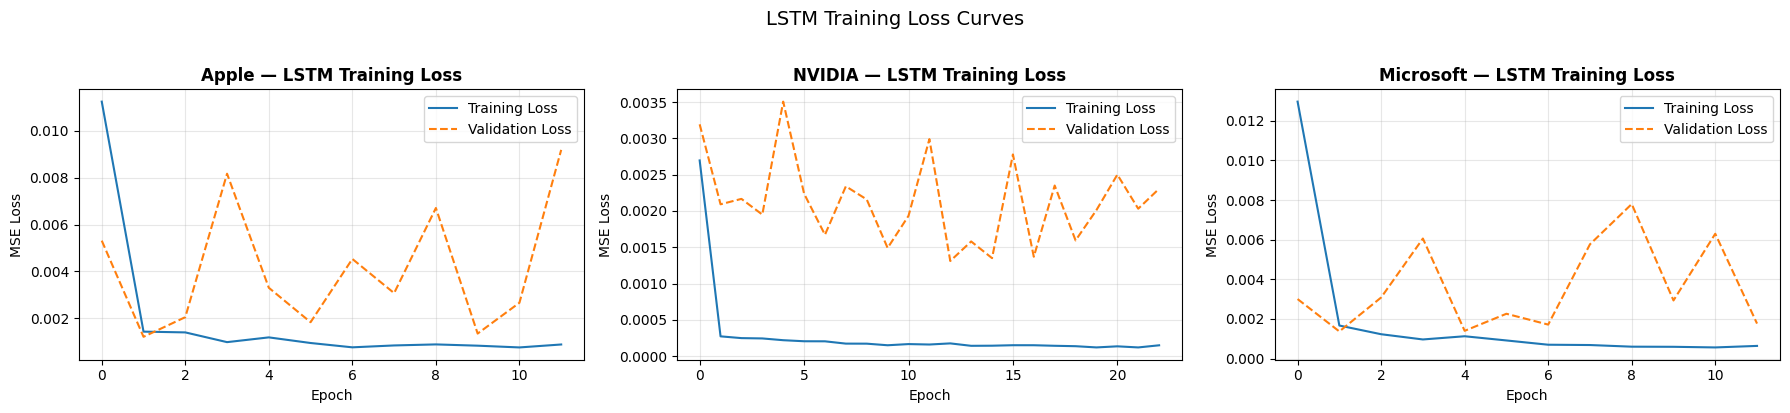

Saved: lstm_training_loss.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for ax, (name, history) in zip(axes, lstm_histories.items()):
    ax.plot(history.history['loss'],     label='Training Loss',   linewidth=1.5)
    ax.plot(history.history['val_loss'], label='Validation Loss', linewidth=1.5, linestyle='--')
    ax.set_title(f'{name} — LSTM Training Loss', fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss')
    ax.legend()

plt.suptitle('LSTM Training Loss Curves', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('lstm_training_loss.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: lstm_training_loss.png')

## 8. Final Results Table

In [ ]:
# build the summary DataFrame
results_df = pd.DataFrame(all_results)

pivot = results_df.pivot_table(
    index=['Stock', 'Ticker'],
    columns='Model',
    values=['RMSE', 'MAE']
).round(2)

# Re-order columns: LR, RF, LSTM
col_order = ['Linear Regression', 'Random Forest', 'LSTM']
pivot = pivot.reindex(col_order, axis=1, level=1)

print('='*65)
print('FINAL RESULTS — RMSE and MAE by Stock and Model (USD)')
print('='*65)
print(pivot.to_string())
print('='*65)

# display flat table
print('\nFlat results table:')
print(results_df.to_string(index=False))

FINAL RESULTS — RMSE and MAE by Stock and Model (USD)
                               MAE                                   RMSE                     
Model            Linear Regression Random Forest   LSTM Linear Regression Random Forest   LSTM
Stock     Ticker                                                                              
Apple     AAPL                2.23          6.11   6.83              2.95          9.13   8.17
Microsoft MSFT                4.20         12.55  11.67              5.47         17.84  14.63
NVIDIA    NVDA                0.70          5.68   1.68              0.95          8.91   2.22

Flat results table:
    Stock Ticker             Model    RMSE     MAE
    Apple   AAPL Linear Regression  2.9541  2.2288
    Apple   AAPL     Random Forest  9.1285  6.1136
    Apple   AAPL              LSTM  8.1702  6.8283
   NVIDIA   NVDA Linear Regression  0.9492  0.7020
   NVIDIA   NVDA     Random Forest  8.9134  5.6758
   NVIDIA   NVDA              LSTM  2.2151  1.677

In [ ]:
results_df.to_csv('results_summary.csv', index=False)
print('Results saved to results_summary.csv')

# highlights the best (lowest) RMSE per stock
print('\nBest model per stock (lowest RMSE):')
best = results_df.loc[results_df.groupby('Stock')['RMSE'].idxmin(), ['Stock', 'Model', 'RMSE', 'MAE']]
print(best.to_string(index=False))

Results saved to results_summary.csv

Best model per stock (lowest RMSE):
    Stock             Model   RMSE    MAE
    Apple Linear Regression 2.9541 2.2288
Microsoft Linear Regression 5.4661 4.2046
   NVIDIA Linear Regression 0.9492 0.7020


## 9. Bar Chart — RMSE Comparison Across All Models and Stocks

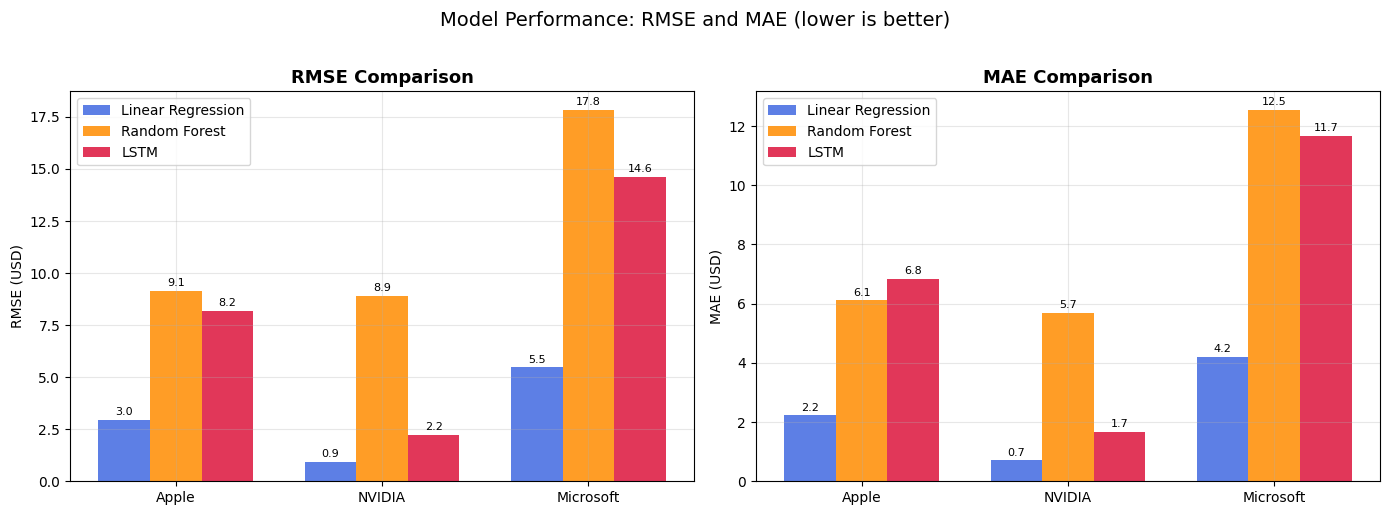

Saved: model_comparison_bar.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
models    = ['Linear Regression', 'Random Forest', 'LSTM']
bar_colours = ['royalblue', 'darkorange', 'crimson']
x         = np.arange(len(TICKERS))
width     = 0.25

for ax, metric in zip(axes, ['RMSE', 'MAE']):
    for i, (model, colour) in enumerate(zip(models, bar_colours)):
        vals = [
            results_df.loc[
                (results_df['Stock'] == stock) & (results_df['Model'] == model),
                metric
            ].values[0]
            for stock in TICKERS.keys()
        ]
        bars = ax.bar(x + i * width, vals, width, label=model, color=colour, alpha=0.85)
        ax.bar_label(bars, fmt='%.1f', fontsize=8, padding=2)

    ax.set_xticks(x + width)
    ax.set_xticklabels(list(TICKERS.keys()))
    ax.set_title(f'{metric} Comparison', fontsize=13, fontweight='bold')
    ax.set_ylabel(f'{metric} (USD)')
    ax.legend()

plt.suptitle('Model Performance: RMSE and MAE (lower is better)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('model_comparison_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: model_comparison_bar.png')

---
## Summary of Outputs

| File | Description |
|---|---|
| `closing_prices.png` | Historical closing prices for all three stocks |
| `pred_vs_actual_AAPL.png` | Predicted vs actual prices — Apple |
| `pred_vs_actual_NVDA.png` | Predicted vs actual prices — NVIDIA |
| `pred_vs_actual_MSFT.png` | Predicted vs actual prices — Microsoft |
| `lstm_training_loss.png` | Training and validation loss curves for all three LSTMs |
| `model_comparison_bar.png` | Bar chart comparing RMSE and MAE across all models |
| `results_summary.csv` | Complete results table — ready to paste into your dissertation |